In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import math
import warnings
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_curve, auc)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [3]:
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


#### 전처리

In [4]:
df.drop(columns=['customerID'], inplace=True)

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

categorical_features = df.select_dtypes(include=['object']).columns.tolist()
numerical_features = df.select_dtypes(include=['int64', 'float64']).drop(columns=['Churn']).columns.tolist()


In [5]:
print(f"범주형 피처 ({len(categorical_features)}개): {categorical_features}")
print(f"수치형 피처 ({len(numerical_features)}개): {numerical_features}")
print(f"이탈률: {df['Churn'].mean():.2%}")

범주형 피처 (15개): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
수치형 피처 (4개): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
이탈률: 26.54%


#### EDA : 범주형

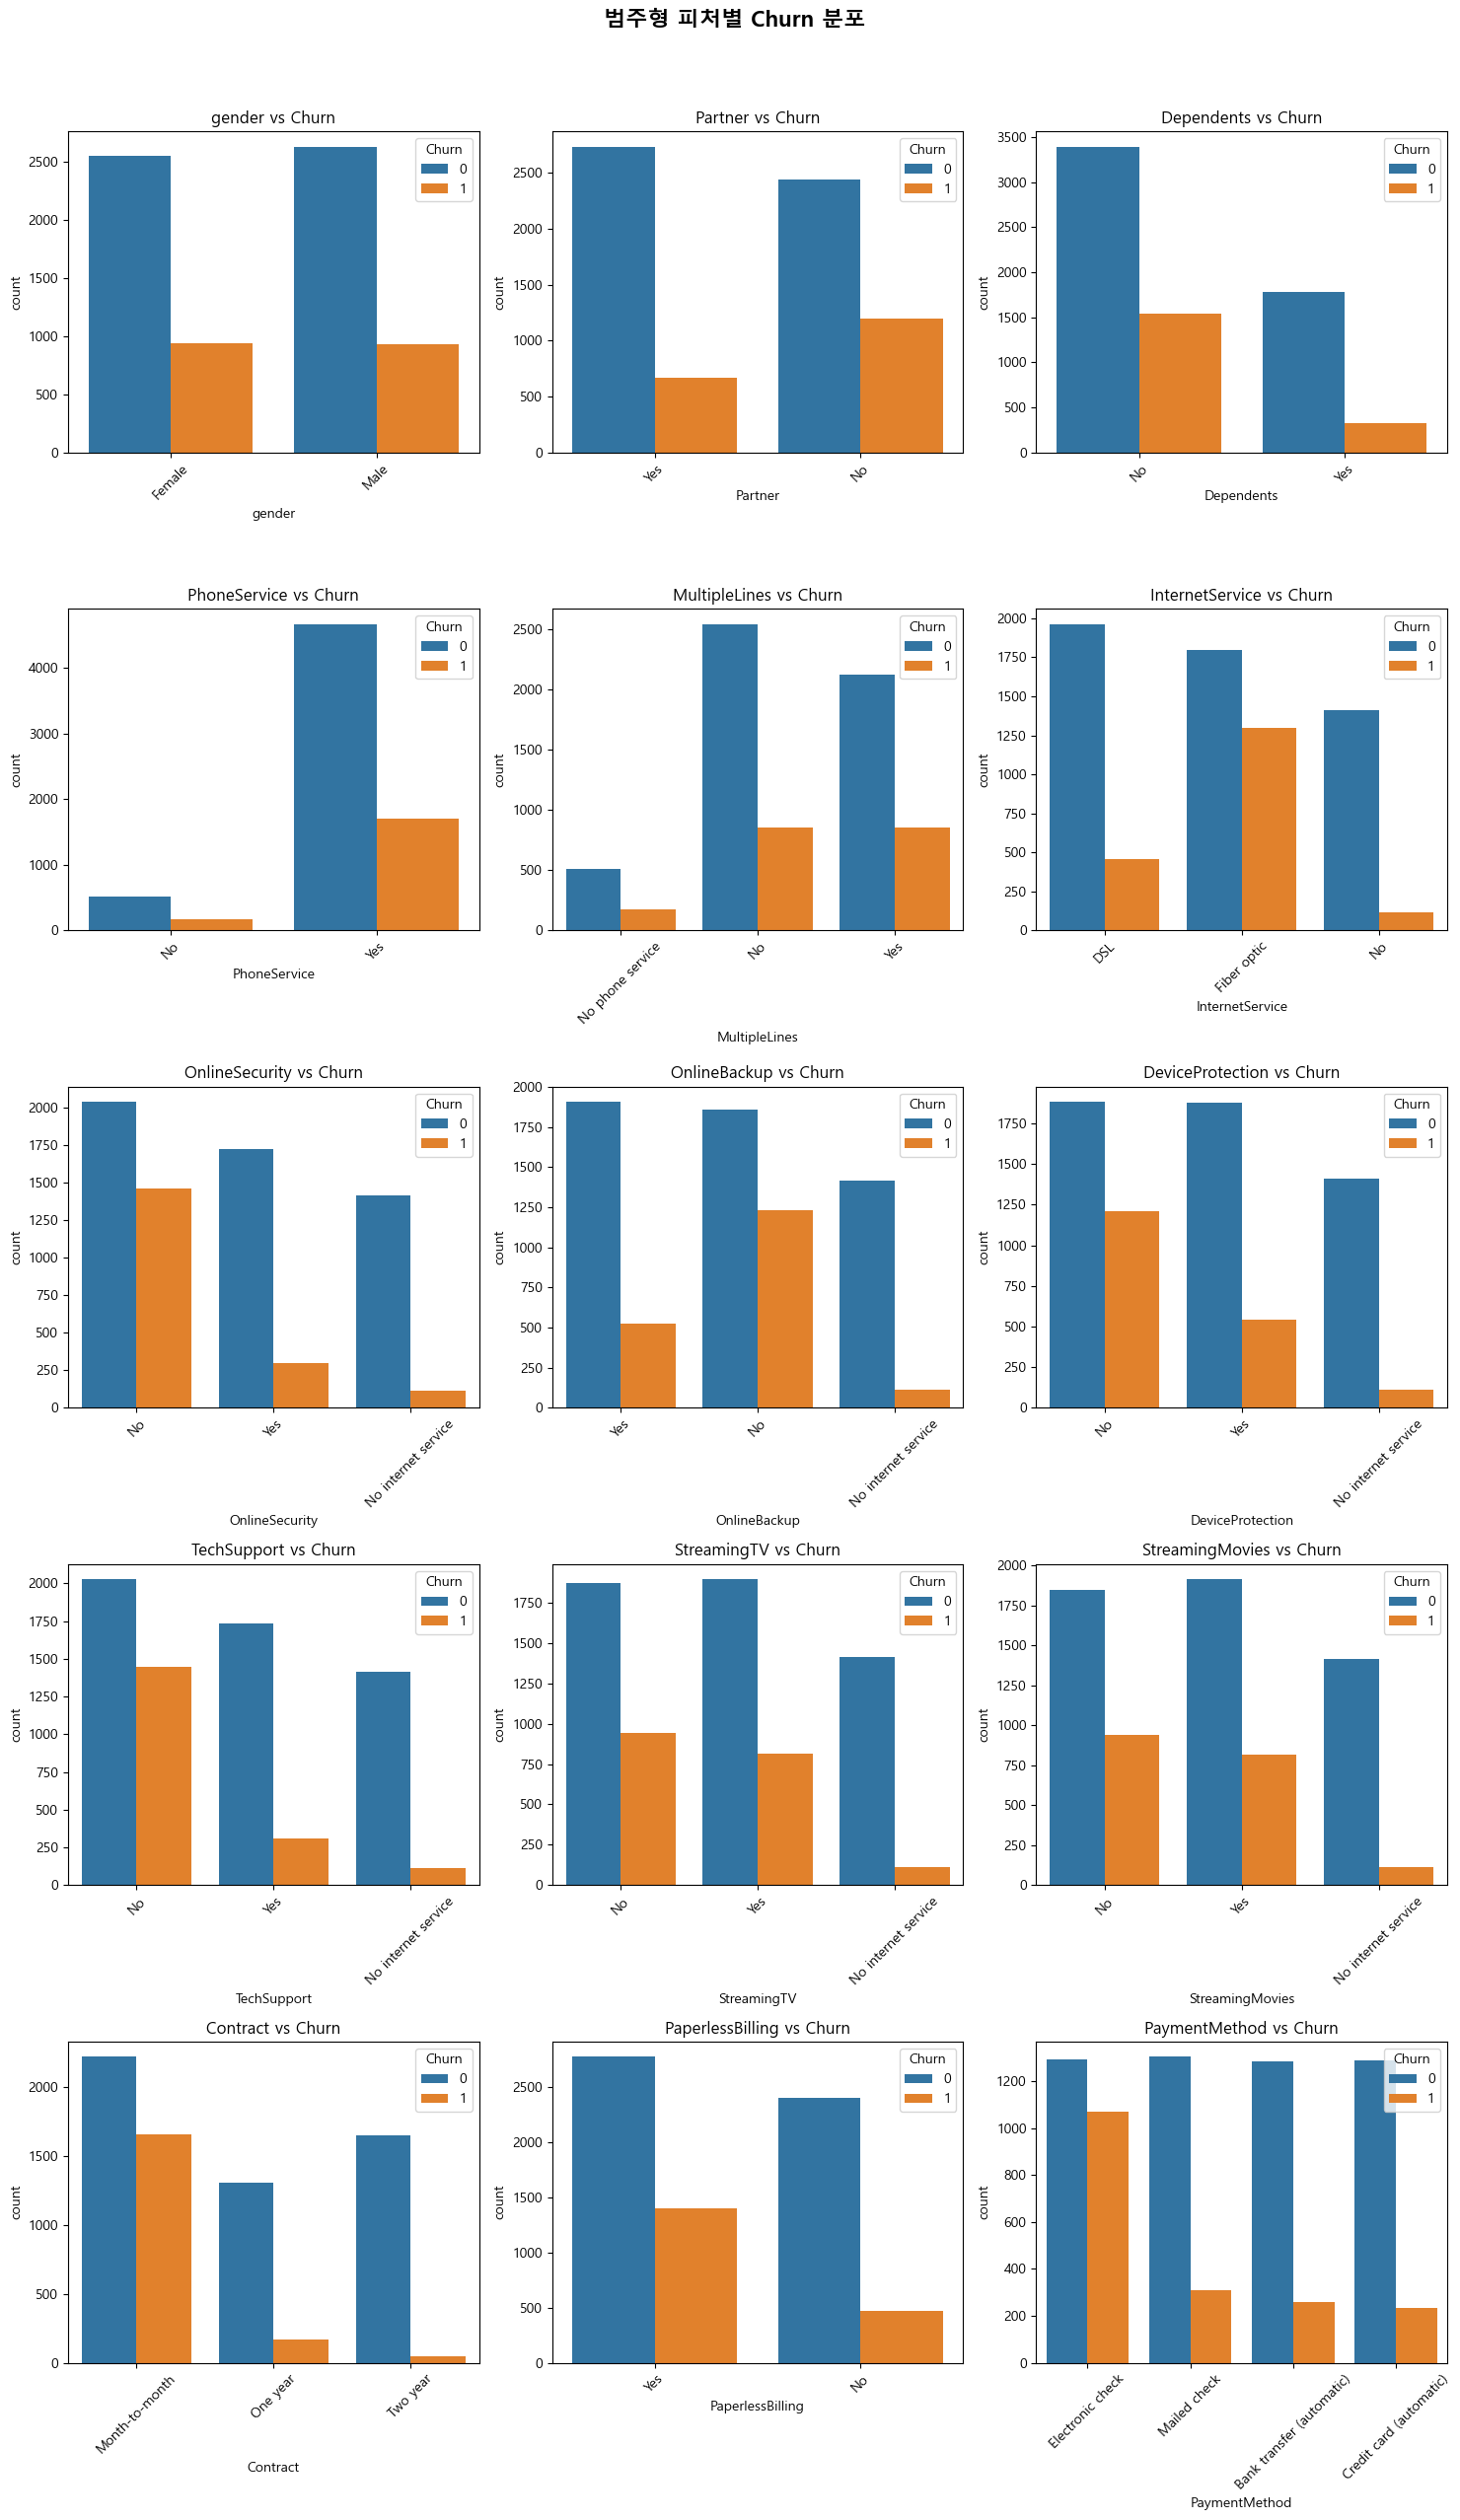

In [6]:
num_features = len(categorical_features)
rows = math.ceil(num_features / 3)
fig, axes = plt.subplots(nrows=rows, ncols=3, figsize=(15, 5 * rows))
axes = axes.flatten()

for i, feature in enumerate(categorical_features):
    sns.countplot(x=feature, hue='Churn', data=df, ax=axes[i])
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)
    axes[i].set_title(f'{feature} vs Churn')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('범주형 피처별 Churn 분포', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

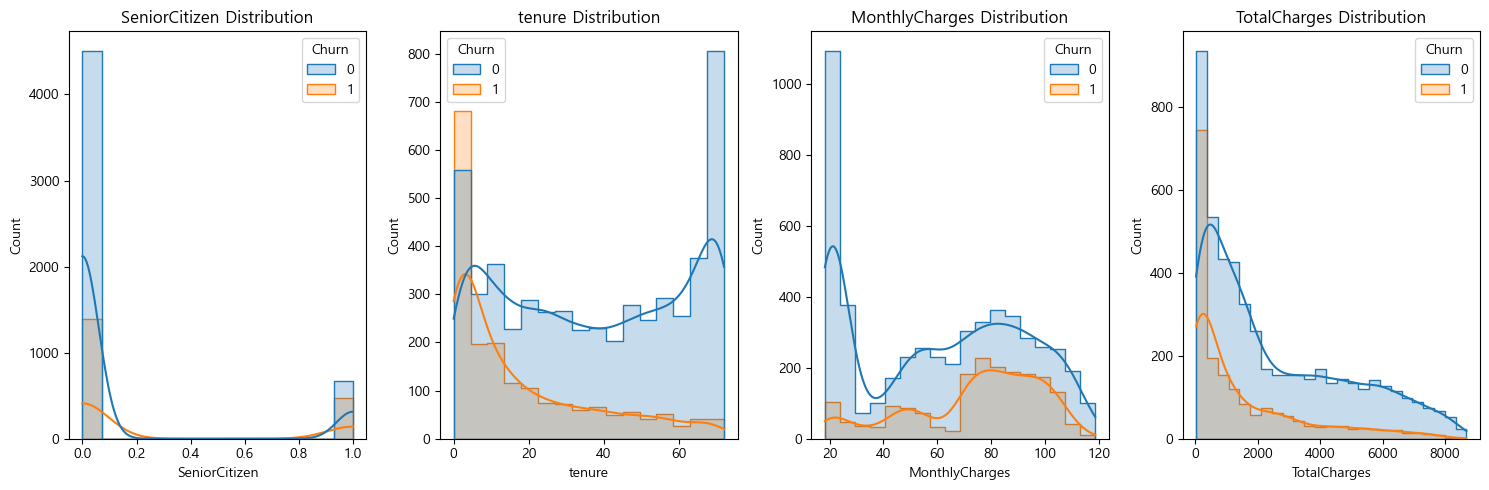

In [7]:
fig, axes = plt.subplots(nrows=1, ncols=len(numerical_features), figsize=(15, 5))
if len(numerical_features) == 1:
    axes = [axes]

for i, feature in enumerate(numerical_features):
    sns.histplot(df, x=feature, hue='Churn', kde=True, element='step', ax=axes[i])
    axes[i].set_title(f'{feature} Distribution')

plt.tight_layout()
plt.show()

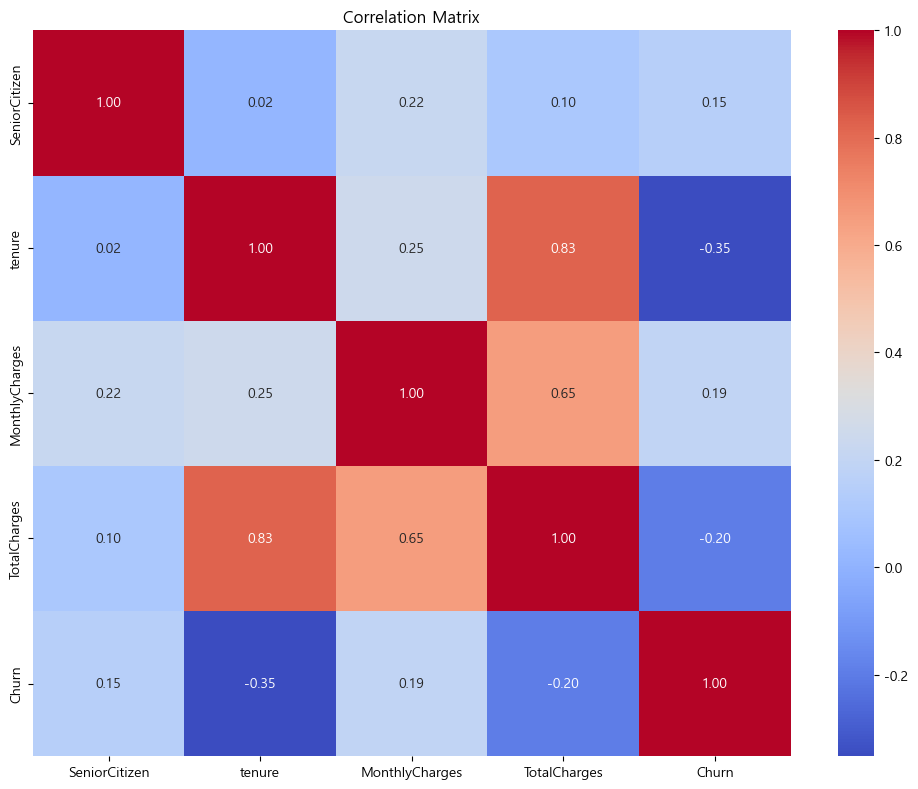

In [8]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[numerical_features + ['Churn']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [9]:
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer, numerical_features),
    ('cat', categorical_transformer, categorical_features)
])

X = df.drop('Churn', axis=1)
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep  = preprocessor.transform(X_test)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_prep, y_train)

print(f"SMOTE 전: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"SMOTE 후: {dict(zip(*np.unique(y_train_res, return_counts=True)))}")

SMOTE 전: {0: 4139, 1: 1495}
SMOTE 후: {0: 4139, 1: 4139}


  File "c:\Users\color\AppData\Local\Programs\Python\Python310\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "c:\Users\color\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 503, in run
    with Popen(*popenargs, **kwargs) as process:
  File "c:\Users\color\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 971, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\color\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 1456, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,


In [10]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred       = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    accuracy  = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall    = recall_score(y_test, y_pred)
    f1        = f1_score(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc   = auc(fpr, tpr)

    print(f"\n[{model_name}]")
    print(f"Accuracy: {accuracy:.4f} | Precision: {precision:.4f} | "
          f"Recall: {recall:.4f} | F1: {f1:.4f} | AUC: {roc_auc:.4f}")

    plt.figure(figsize=(6, 5))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='g', cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

    return {'model_name': model_name, 'accuracy': accuracy, 'precision': precision,
            'recall': recall, 'f1': f1, 'auc': roc_auc, 'fpr': fpr, 'tpr': tpr}


[Logistic Regression]
Accuracy: 0.7374 | Precision: 0.5034 | Recall: 0.7941 | F1: 0.6162 | AUC: 0.8400


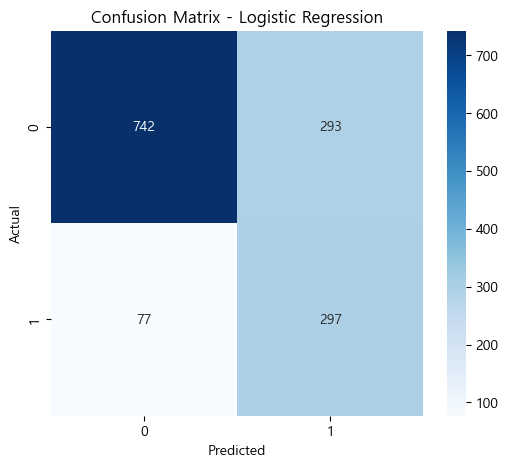


[Random Forest]
Accuracy: 0.7679 | Precision: 0.5651 | Recall: 0.5455 | F1: 0.5551 | AUC: 0.8145


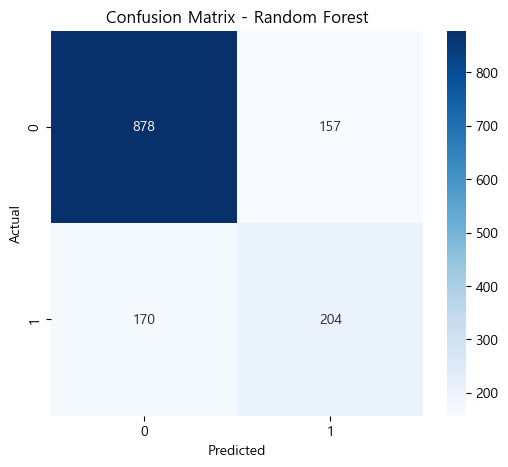


[XGBoost]
Accuracy: 0.7842 | Precision: 0.5946 | Recall: 0.5882 | F1: 0.5914 | AUC: 0.8171


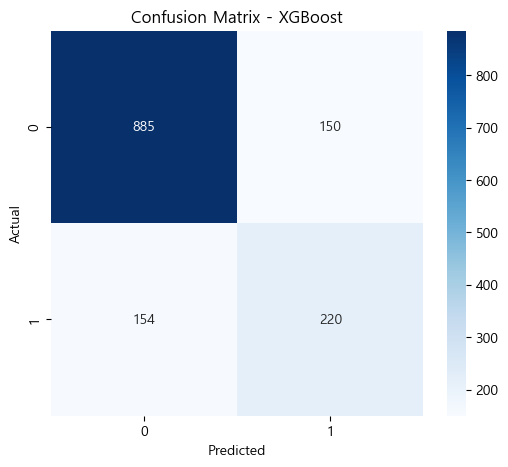

In [11]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(random_state=42),
    'XGBoost':             XGBClassifier(random_state=42, eval_metric='logloss')
}

results = []
for model_name, model in models.items():
    model.fit(X_train_res, y_train_res)
    results.append(evaluate_model(model, X_test_prep, y_test, model_name))

Fitting 5 folds for each of 18 candidates, totalling 90 fits

최적 파라미터: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}

[Optimized Random Forest]
Accuracy: 0.7771 | Precision: 0.5798 | Recall: 0.5829 | F1: 0.5813 | AUC: 0.8209


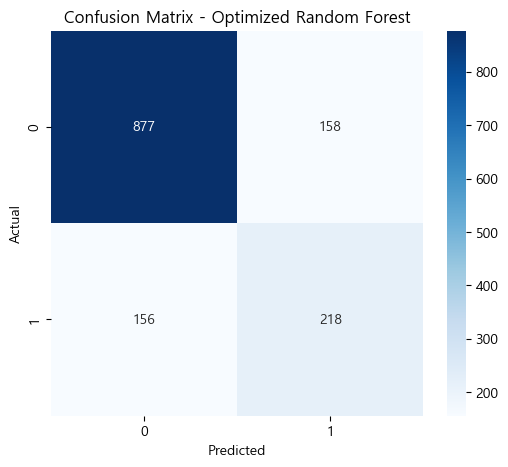

In [12]:
param_grid = {
    'n_estimators':      [100, 200],
    'max_depth':         [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1
)
grid_search.fit(X_train_res, y_train_res)

print("\n최적 파라미터:", grid_search.best_params_)
best_model = grid_search.best_estimator_
results.append(evaluate_model(best_model, X_test_prep, y_test, "Optimized Random Forest"))


[Ensemble Model]
Accuracy: 0.7821 | Precision: 0.5852 | Recall: 0.6150 | F1: 0.5997 | AUC: 0.8338


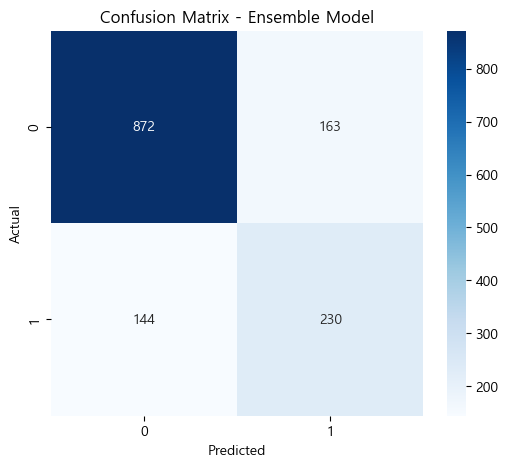

In [13]:
ensemble_model = VotingClassifier(estimators=[
    ('rf',  best_model),
    ('xgb', XGBClassifier(random_state=42, eval_metric='logloss')),
    ('gb',  GradientBoostingClassifier(random_state=42))
], voting='soft')
ensemble_model.fit(X_train_res, y_train_res)
results.append(evaluate_model(ensemble_model, X_test_prep, y_test, "Ensemble Model"))

             model_name  accuracy  precision   recall       f1      auc
    Logistic Regression  0.737402   0.503390 0.794118 0.616183 0.840019
         Ensemble Model  0.782115   0.585242 0.614973 0.599739 0.833796
Optimized Random Forest  0.777147   0.579787 0.582888 0.581333 0.820890
                XGBoost  0.784244   0.594595 0.588235 0.591398 0.817062
          Random Forest  0.767921   0.565097 0.545455 0.555102 0.814532


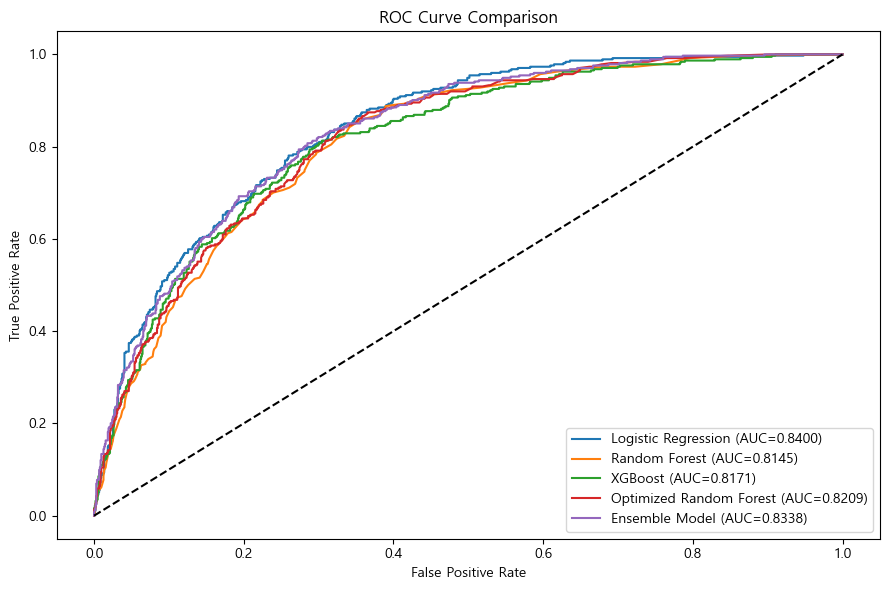

In [14]:
results_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ('fpr', 'tpr')} for r in results])
print(results_df.sort_values('auc', ascending=False).to_string(index=False))

plt.figure(figsize=(9, 6))
for r in results:
    plt.plot(r['fpr'], r['tpr'], label=f"{r['model_name']} (AUC={r['auc']:.4f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

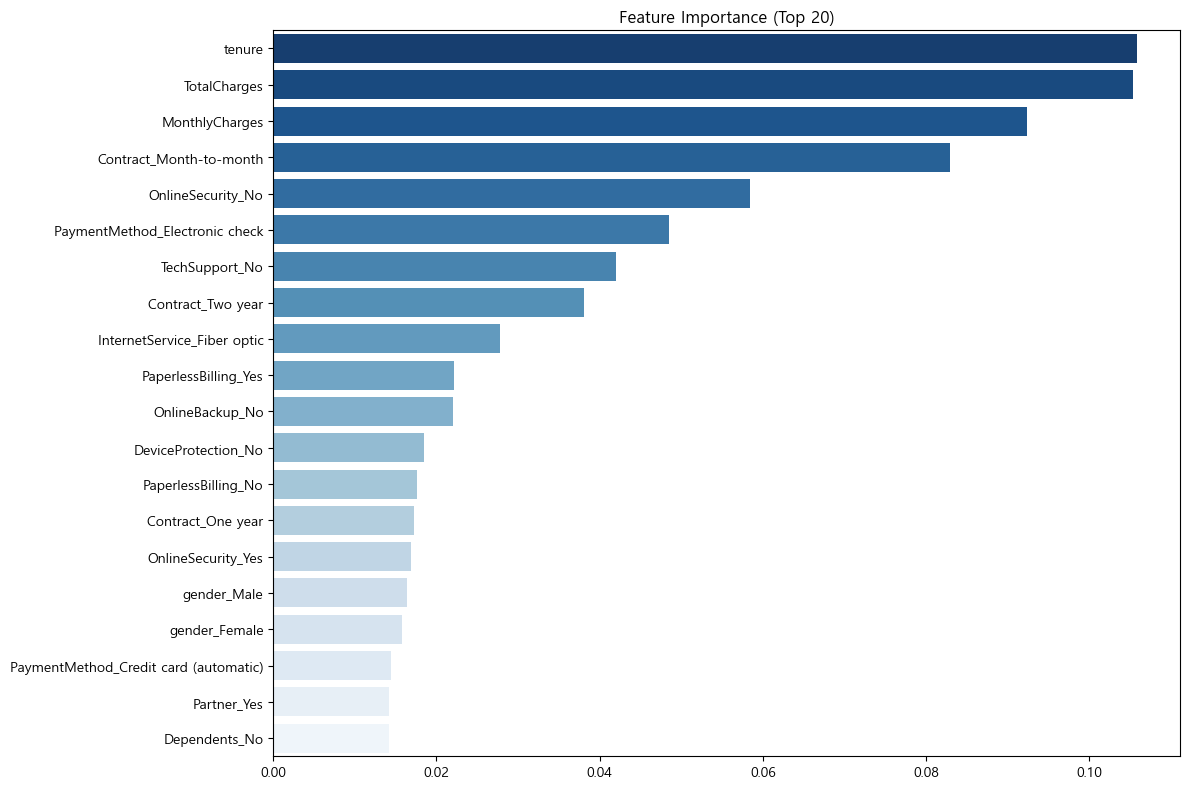

In [15]:
feature_names = (numerical_features +
    preprocessor.named_transformers_['cat']
                 .named_steps['onehot']
                 .get_feature_names_out(categorical_features).tolist())

importances = best_model.feature_importances_
sorted_idx  = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 8))
sns.barplot(y=np.array(feature_names)[sorted_idx][:20],
            x=importances[sorted_idx][:20], palette='Blues_r')
plt.title('Feature Importance (Top 20)')
plt.tight_layout()
plt.show()

#### 비즈니스 인사이트 & 액션 아이템

#### 주요 이탈 위험 요인 (Feature Importance 기반)
| 순위 | 피처 | 해석 |
|------|------|------|
| 1 | MonthlyCharges | 요금 높을수록 이탈 위험 증가 |
| 2 | tenure | 가입 초기 6개월 이내 이탈 집중 |
| 3 | Contract | Month-to-month 단기 계약 고객이 가장 취약 |
| 4 | TotalCharges | 누적 결제액 낮은 고객 = 조기 이탈 가능성 높음 |

#### 액션 아이템
1. **조기 이탈 방지** : tenure 6개월 이내 + MonthlyCharges > 70 고객 → 온보딩 강화 + 할인 프로모션 우선 적용
2. **Lock-in 전략** : Month-to-month → 1년 계약 전환 인센티브
3. **번들 판매** : 추가 서비스 가입 고객일수록 이탈률 낮음 → 온보딩 시 서비스 번들 제안
4. **고위험군 스코어링** : 본 모델(AUC ~0.84) 활용 → 매월 이탈 위험 고객 추출 후 CRM 연동